In [1]:
import matplotlib.pylab as pl
import numpy as np

import ot

### Generate data

In [2]:
n = 200  # nb samples

mu_s = np.array([0, 0])
cov_s = np.array([[1, 0], [0, 1]])

mu_t = np.array([4, 4])
cov_t = np.array([[1, -0.8], [-0.8, 1]])

xs = ot.datasets.make_2D_samples_gauss(n, mu_s, cov_s)
xt = ot.datasets.make_2D_samples_gauss(n, mu_t, cov_t)

a, b = np.ones((n,)) / n, np.ones((n,)) / n  # uniform distribution on samples

### Plot data

Text(0.5, 1.0, 'Source and target distributions')

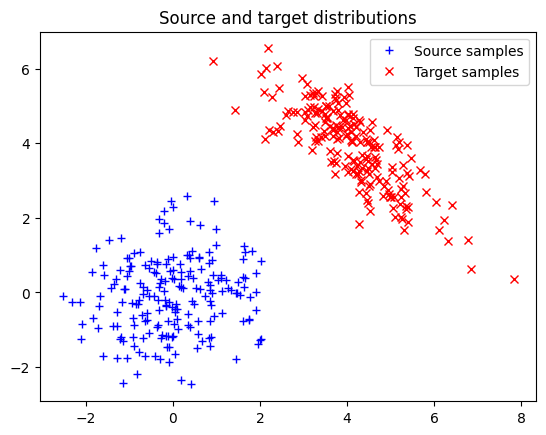

In [3]:
pl.figure(1)
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source samples")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target samples")
pl.legend(loc=0)
pl.title("Source and target distributions")

### Sliced Wasserstein distance for different seeds and number of projections

In [4]:
n_seed = 20
n_projections_arr = np.logspace(0, 3, 10, dtype=int)
res = np.empty((n_seed, 10))

In [5]:
for seed in range(n_seed):
    for i, n_projections in enumerate(n_projections_arr):
        res[seed, i] = ot.sliced_wasserstein_distance(
            xs, xt, a, b, n_projections, seed=seed
        )

res_mean = np.mean(res, axis=0)
res_std = np.std(res, axis=0)

### Plot Sliced Wasserstein Distance

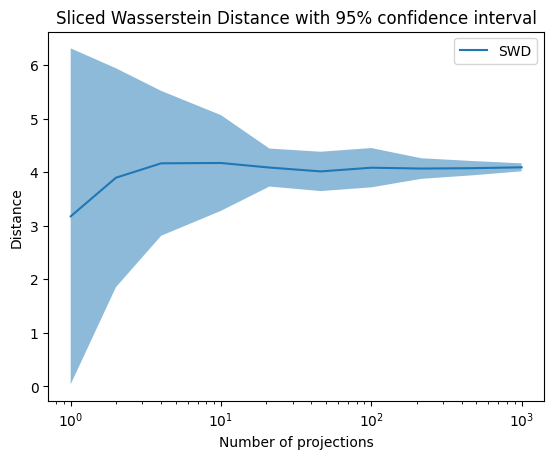

In [6]:
pl.figure(2)
pl.plot(n_projections_arr, res_mean, label="SWD")
pl.fill_between(
    n_projections_arr, res_mean - 2 * res_std, res_mean + 2 * res_std, alpha=0.5
)

pl.legend()
pl.xscale("log")

pl.xlabel("Number of projections")
pl.ylabel("Distance")
pl.title("Sliced Wasserstein Distance with 95% confidence interval")

pl.show()